In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn.pipeline import Pipeline

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.data_pipeline import load_data, clean_data, get_feature_columns, build_preprocessing_pipeline

sns.set_style("whitegrid")

df = load_data("../data/raw/Telco_Customer_Churn.xlsx")
df.shape

(7043, 33)

In [2]:
df = clean_data(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [3]:
numeric_cols, categorical_cols = get_feature_columns(df, target_col="Churn")
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['Tenure Months', 'Monthly Charges', 'Total Charges']
Categorical: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


## Exploratory Data Analysis

In [4]:


churn_rate = df["Churn"].mean()
print(f"Overall churn rate: {churn_rate:.2%}")

Overall churn rate: 26.54%


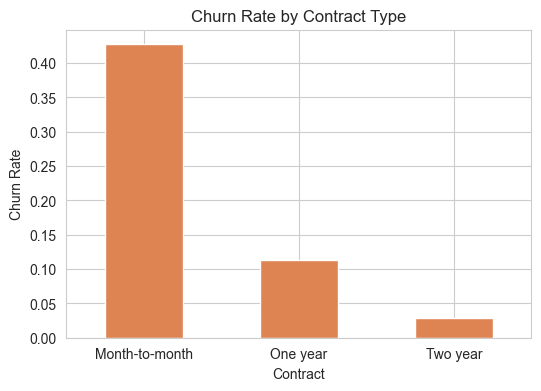

In [5]:
churn_by_contract = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
churn_by_contract.plot(kind="bar", figsize=(6,4), color="#DD8452")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

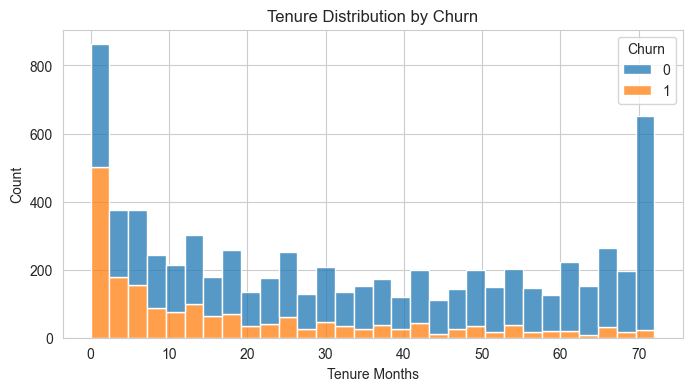

In [6]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="Tenure Months", hue="Churn", bins=30, multiple="stack")
plt.title("Tenure Distribution by Churn")
plt.show()

## Feature Engineering & Preprocessing

In [7]:


from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}, Test churn rate: {y_test.mean():.2%}")

Train shape: (5634, 19), Test shape: (1409, 19)
Train churn rate: 26.54%, Test churn rate: 26.54%


## Model Training

In [8]:


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

preprocessor = build_preprocessing_pipeline(numeric_cols, categorical_cols)

log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", n_estimators=200, random_state=42))
])

log_reg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

## Evaluation


--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC: 0.8489


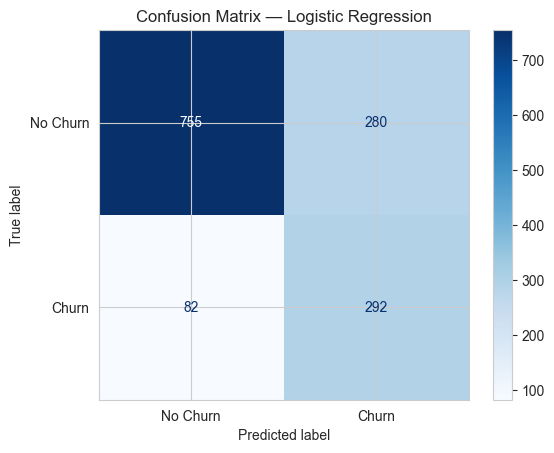

--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8322


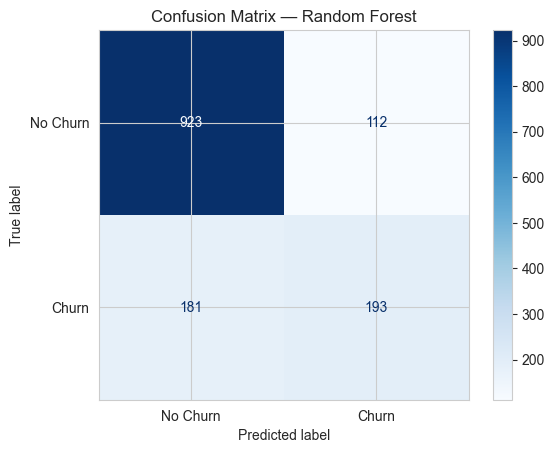

In [9]:

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(pipeline, X_test, y_test, name):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

evaluate_model(log_reg_pipeline, X_test, y_test, "Logistic Regression")
evaluate_model(rf_pipeline, X_test, y_test, "Random Forest")

## Serialize Model

In [10]:


import joblib

joblib.dump(log_reg_pipeline, "../models/churn_model.pkl")
print("Model saved to ../models/churn_model.pkl")

Model saved to ../models/churn_model.pkl


In [11]:
loaded_model = joblib.load("../models/churn_model.pkl")
sample = X_test.iloc[[0]]
print("Prediction:", loaded_model.predict(sample))
print("Probability:", loaded_model.predict_proba(sample))

Prediction: [0]
Probability: [[0.81369571 0.18630429]]
